In [1]:
# Import needed libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make figures look clean 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Folder to save every chart generated (used later in BOTH dashboards)
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)


df = pd.read_csv("../data/raw/ecommerce_customer_churn_large.csv")
df.shape

(200000, 11)

In [2]:
df.dtypes #Check columns' types

customer_id               int64
age                       int64
gender                      str
city                        str
tenure_months             int64
avg_order_value           int64
total_orders              int64
last_purchase_days_ago    int64
support_tickets           int64
subscription_type           str
churn                     int64
dtype: object

In [3]:
df.head() #Check first 5 rows of each col

,customer_id,age,gender,city,tenure_months,avg_order_value,total_orders,last_purchase_days_ago,support_tickets,subscription_type,churn
0,100000,56,Female,Mumbai,82,7722,56,704,49,Basic,1
1,100001,69,Female,Kolkata,28,2127,248,357,39,Basic,0
2,100002,46,Male,Delhi,98,2775,68,121,23,Platinum,0
3,100003,32,Female,Pune,46,1698,309,39,47,Silver,0
4,100004,60,Female,Bangalore,90,6520,147,403,32,Silver,0


In [4]:
df.describe() #Return summary statistics

,customer_id,age,tenure_months,avg_order_value,total_orders,last_purchase_days_ago,support_tickets,churn
count,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,199999.500000,43.47717,59.816265,5103.223420,249.919035,364.573055,24.461705,0.372135
std,57735.171256,14.98306,34.331202,2827.789332,144.009220,210.814554,14.448645,0.483375
min,100000.000000,18.00000,1.000000,200.000000,1.000000,0.000000,0.000000,0.000000
25%,149999.750000,31.00000,30.000000,2655.000000,125.000000,182.000000,12.000000,0.000000
50%,199999.500000,43.00000,60.000000,5094.000000,250.000000,364.000000,24.000000,0.000000
75%,249999.250000,56.00000,90.000000,7547.000000,375.000000,547.000000,37.000000,1.000000
max,299999.000000,69.00000,119.000000,9999.000000,499.000000,729.000000,49.000000,1.000000


In [5]:
df.isnull().sum() #Chechk null - if none then it's clear

customer_id               0
age                       0
gender                    0
city                      0
tenure_months             0
avg_order_value           0
total_orders              0
last_purchase_days_ago    0
support_tickets           0
subscription_type         0
churn                     0
dtype: int64

In [6]:
df.describe(include="object") # unique count for each category

/var/folders/q9/xcd2r8491s77y7dyw9dmh4wm0000gn/T/ipykernel_63301/3869233533.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object") # unique count for each category


,gender,city,subscription_type
count,200000,200000,200000
unique,2,7,4
top,Female,Kolkata,Basic
freq,100088,28837,80063


In [7]:
df["customer_id"].duplicated().sum() #Check duplicated cases in customer id

np.int64(0)

In [8]:
customer_index = df["customer_id"].copy() #Save backup copy for later use
df = df.drop(columns=["customer_id"]) #Drop Customer ID column
df.shape

(200000, 10)

In [14]:
# Check proportion of some categories
df["gender"].value_counts(normalize=True)
df["city"].value_counts(normalize=True)

city
Kolkata      0.144185
Hyderabad    0.143425
Bangalore    0.143395
Mumbai       0.142610
Pune         0.142530
Chennai      0.141935
Delhi        0.141920
Name: proportion, dtype: float64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   age                     200000 non-null  int64
 1   gender                  200000 non-null  str  
 2   city                    200000 non-null  str  
 3   tenure_months           200000 non-null  int64
 4   avg_order_value         200000 non-null  int64
 5   total_orders            200000 non-null  int64
 6   last_purchase_days_ago  200000 non-null  int64
 7   support_tickets         200000 non-null  int64
 8   subscription_type       200000 non-null  str  
 9   churn                   200000 non-null  int64
dtypes: int64(7), str(3)
memory usage: 18.5 MB


In [13]:
# Class balance for churn column
balance = df["churn"].value_counts(normalize=True).rename({0:"Retained", 1:"Churned"})
print(balance)

churn
Retained    0.627865
Churned     0.372135
Name: proportion, dtype: float64


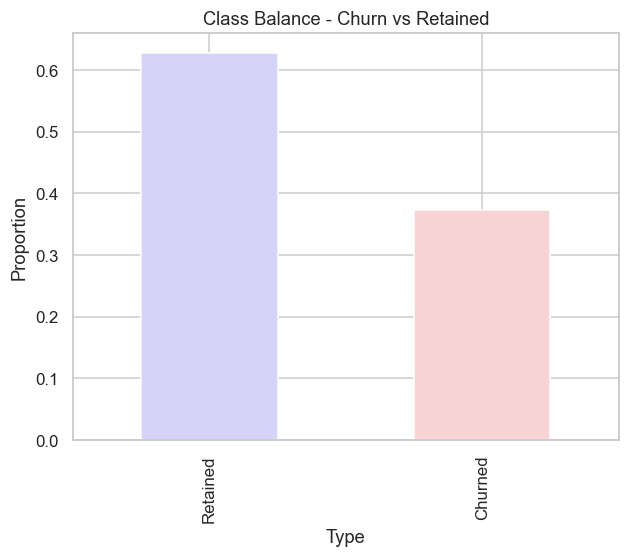

In [26]:
ax = balance.plot(kind="bar", color=["#D6D3F8", "#F8D3D3"])
ax.set_title("Class Balance - Churn vs Retained")
ax.set_ylabel("Proportion")
ax.set_xlabel("Type")
plt.savefig(f"{FIG_DIR}/class_balance.png",bbox_inches="tight")
plt.show()


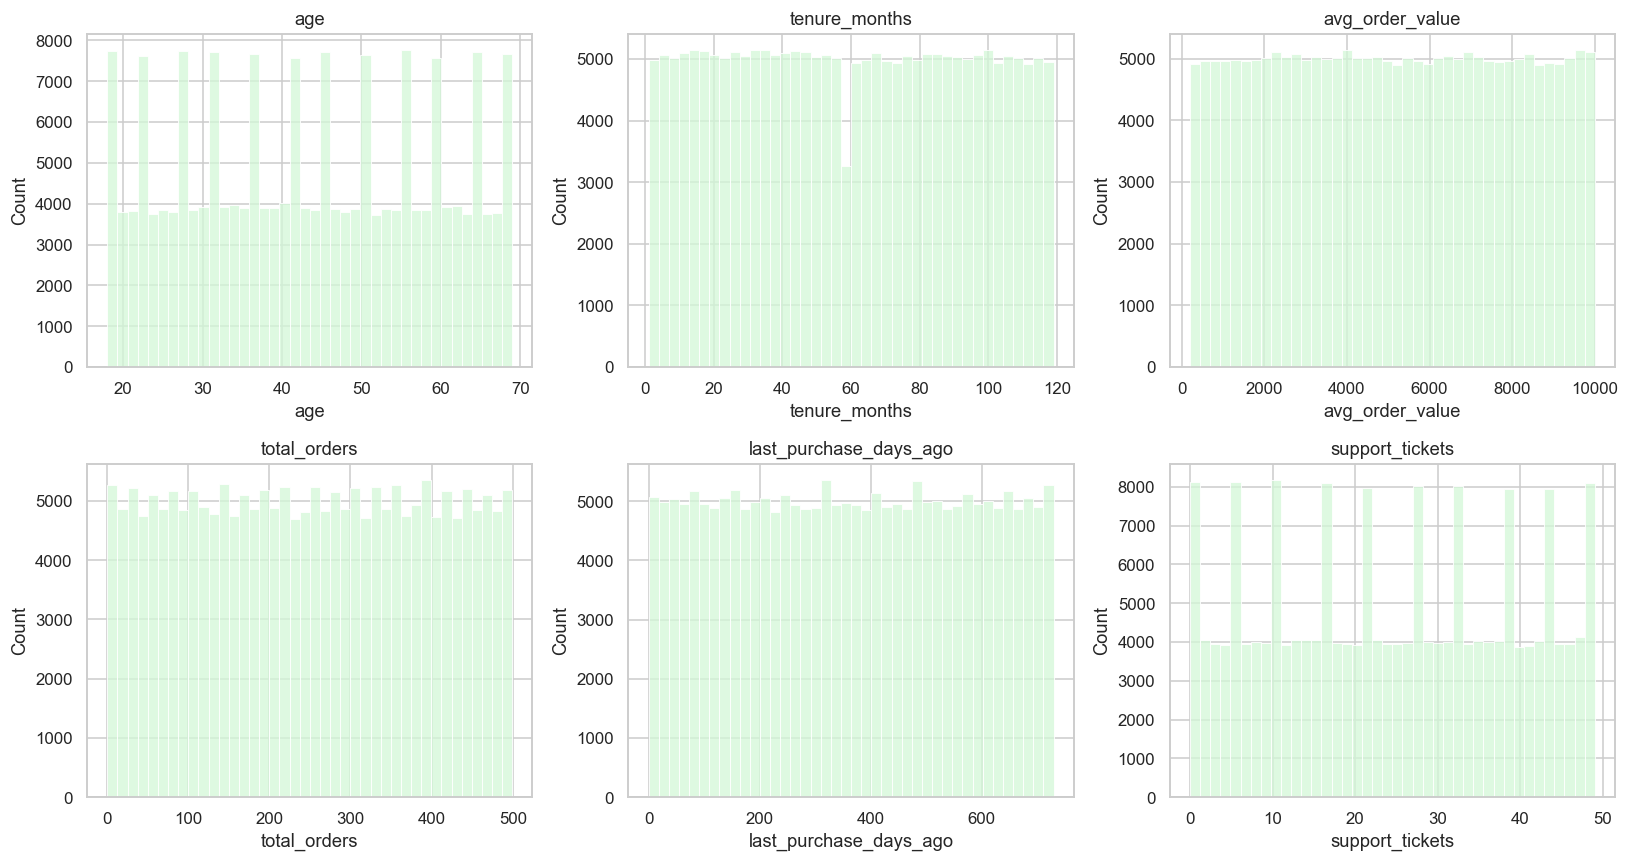

In [27]:
# EDA
# Numeric Histograms
numeric_cols = ["age", "tenure_months", "avg_order_value","total_orders",
                 "last_purchase_days_ago", "support_tickets"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df, x=col, bins=40, ax=ax, color="#D3F8D8")
    ax.set_title(col)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/univariate_numeric.png", bbox_inches="tight")
plt.show()

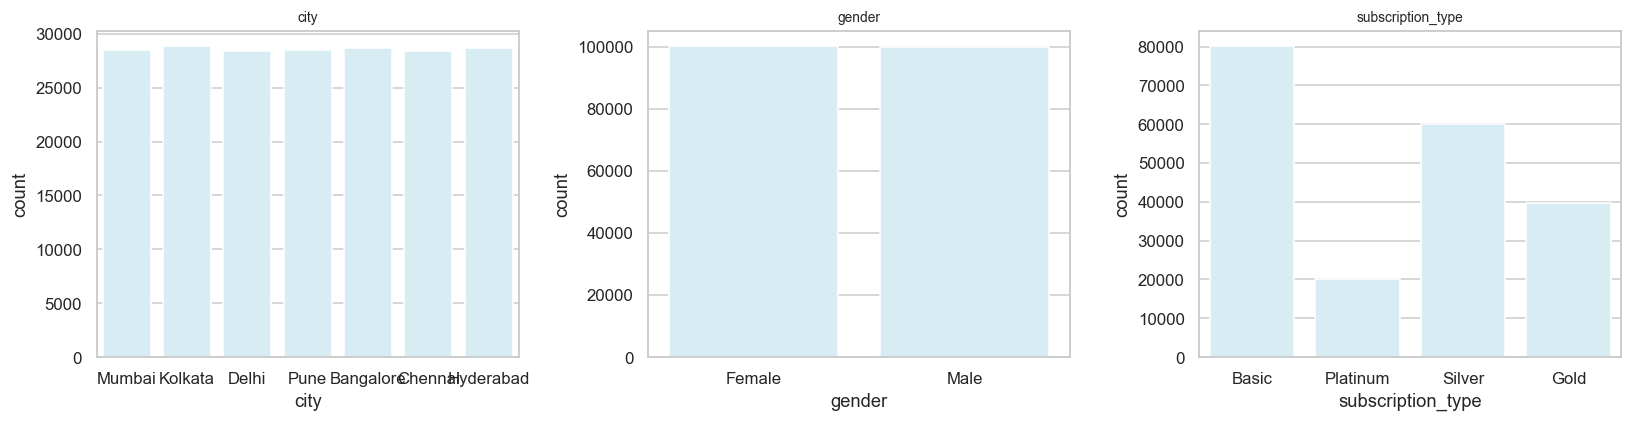

In [30]:
# Categorical Bar Charts
cat_cols = ["city", "gender", "subscription_type"]
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, color="#D3F0F8")
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/univariate_categorical.png", bbox_inches="tight")
plt.show()

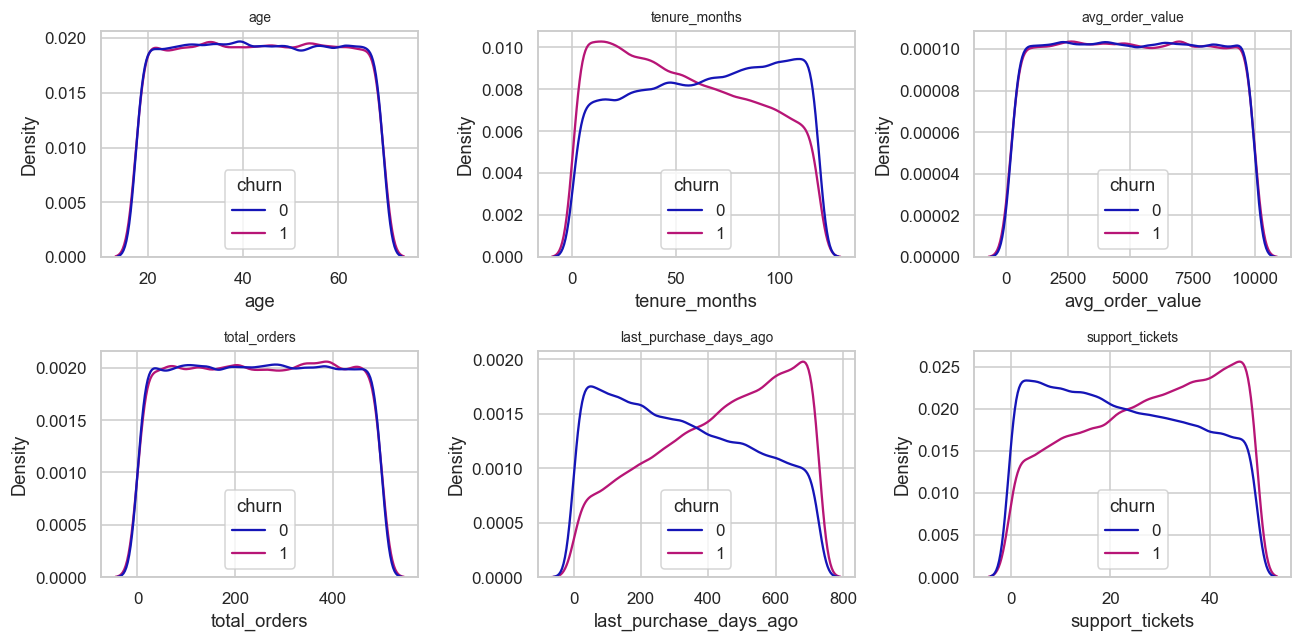

In [38]:
# Checking relationship between "Churn" and numerical categories
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.kdeplot(data=df, x=col, hue="churn", ax=ax, common_norm=False, palette={0:"#1515B7",1:"#B71576"})
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


age:
age
18-25    0.3732
25-35    0.3721
35-50    0.3701
50-65    0.3733
65+      0.3738
Name: churn, dtype: float64

tenure_months:
tenure_months
0-6mo     0.4697
6-12mo    0.4469
1-2yr     0.4489
2yr+      0.3514
Name: churn, dtype: float64

last_purchase_days_ago:
last_purchase_days_ago
0-30d      0.1797
30-90d     0.2050
90-180d    0.2474
180d+      0.4217
Name: churn, dtype: float64

support_tickets:
support_tickets
0       0.2399
1-3     0.2598
4-10    0.2841
10+     0.4001
Name: churn, dtype: float64


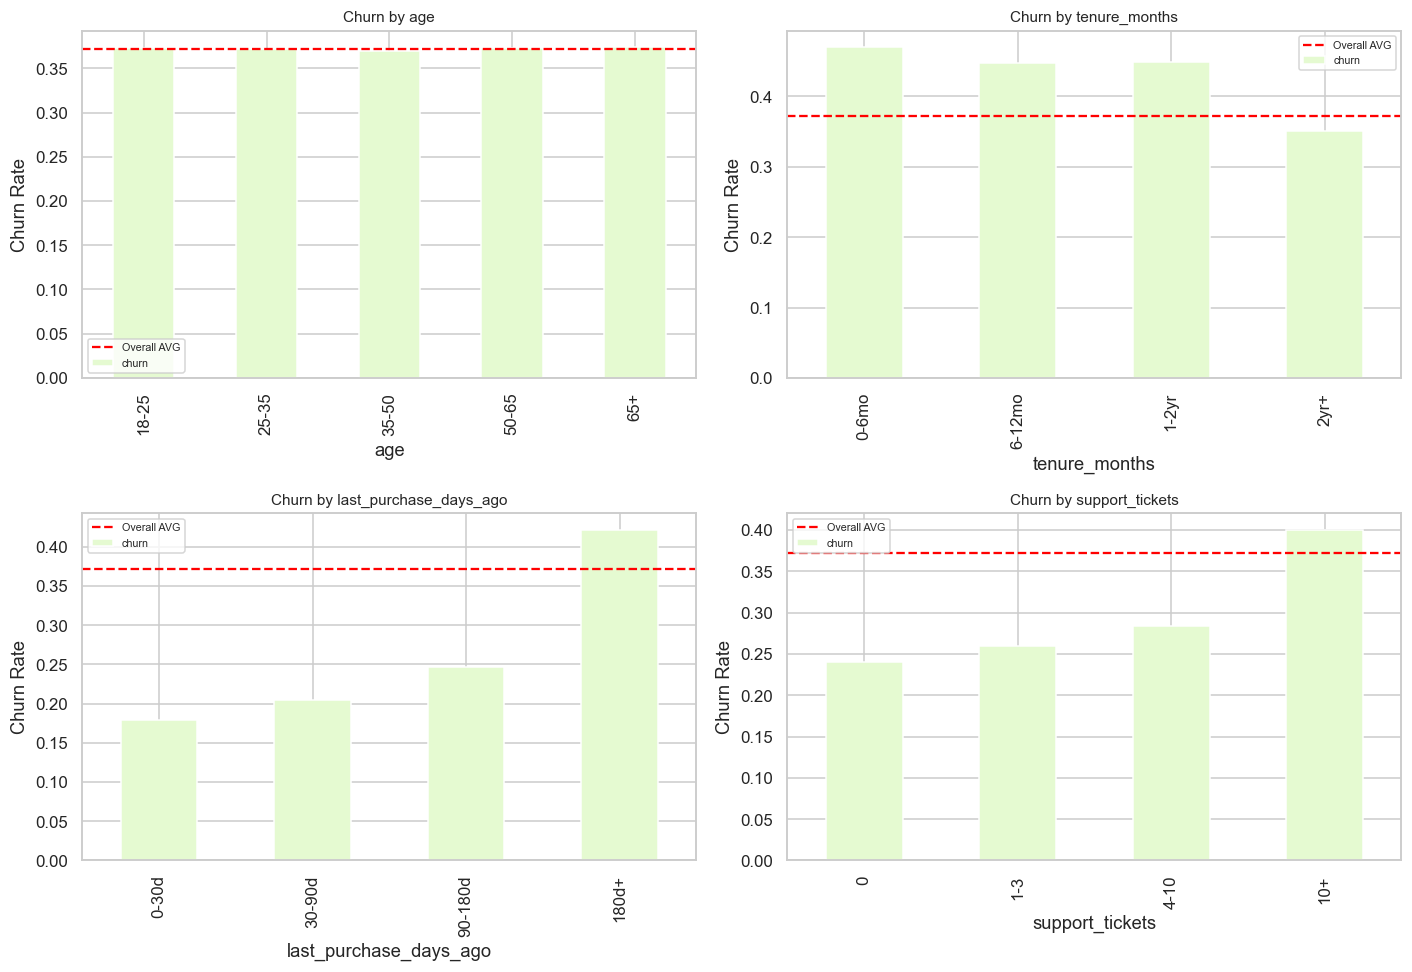

In [41]:
 # Checking relationship between "Churn" and banded features
band_specs = {"age":([17, 25, 35, 50, 65, 100],["18-25","25-35","35-50","50-65","65+"]),
              "tenure_months":([-1, 6, 12, 24, 1000],["0-6mo","6-12mo","1-2yr","2yr+"]),
              "last_purchase_days_ago": ([-1, 30, 90, 180, 100000],["0-30d","30-90d","90-180d","180d+"]),
              "support_tickets": ([-1, 0, 3, 10, 1000],["0","1-3","4-10","10+"])}
overall = df["churn"].mean()
fig, axes = plt.subplots(2, 2, figsize=(13,9))
axes=axes.flatten()
for ax, (col, spec) in zip(axes, band_specs.items()):
    bins, labels = spec
    band = pd.cut(df[col], bins=bins, labels=labels)
    rates = df.groupby(band, observed=True)["churn"].mean()
    print(f"\n{col}:\n{rates.round(4)}")

    rates.plot(kind="bar", ax=ax, color="#E5FAD1")
    ax.axhline(overall, color="red", linestyle="--",label="Overall AVG")
    ax.set_title(f"Churn by {col}", fontsize=10)
    ax.set_ylabel("Churn Rate")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/churn_by_bands.png",bbox_inches="tight")
plt.show()

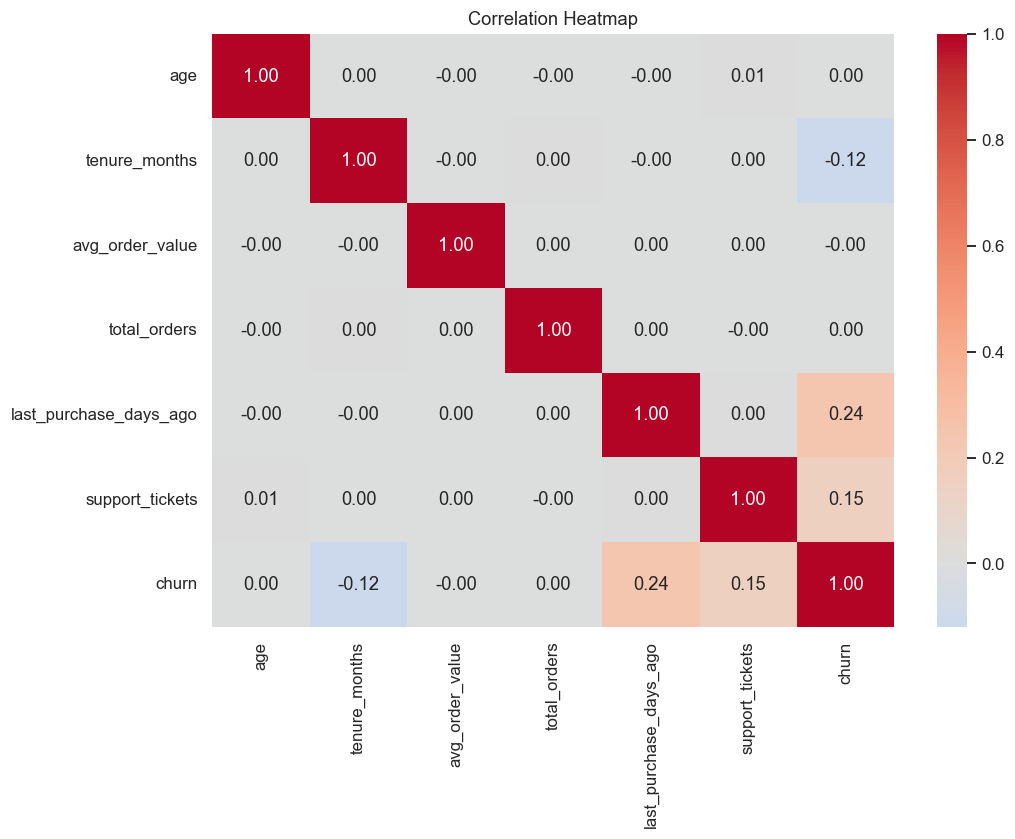

In [42]:
# Correlation Map
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.savefig(f"{FIG_DIR}/correlation_heatmap.png",bbox_inches="tight")
plt.show()